<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112---Assignment-02/blob/main/Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-20 003555.png to Screenshot 2026-03-20 003555 (7).png
RANSAC Slope: 0.09031907872260667
RANSAC Intercept: 127.02207516069755


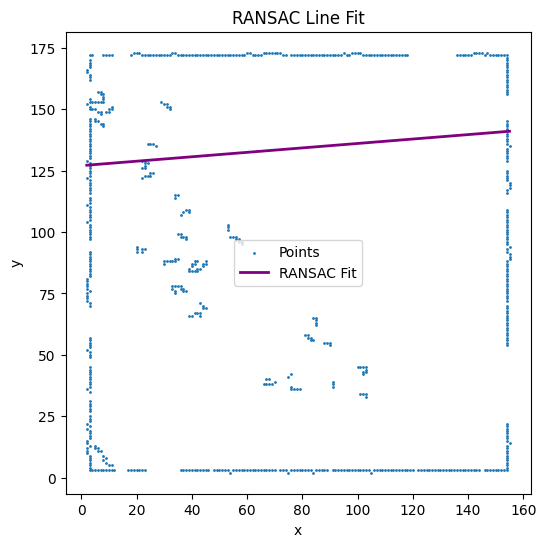

In [11]:


import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from google.colab import files

# Upload image
uploaded = files.upload()

# Read image
img = cv.imread('/content/1c.png', 0)

# Edge detection
edges = cv.Canny(img, 550, 690)

# Extract points
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

# Prepare data
x_reshaped = x.reshape(-1,1)

# RANSAC
ransac = RANSACRegressor()
ransac.fit(x_reshaped, y)

m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

print("RANSAC Slope:", m_ransac)
print("RANSAC Intercept:", c_ransac)

# Plot
x_line = np.linspace(min(x), max(x), 100)
y_line = m_ransac * x_line + c_ransac

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, label="Points")
plt.plot(x_line, y_line, color='purple', linewidth=2, label="RANSAC Fit")

plt.title("RANSAC Line Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()